# **3.1 Linear Regression**
**Regression is a class of methods that can model the relationship between one or more independent variables and a dependent variable.** In the natural and social sciences, regression is often used to describe the relationship between input and output.<br><br>
Most tasks in the field of machine learning typically involve prediction. When we want to predict a numerical value, we are dealing with a regression problem. **But not all predictions are regression problems.** The goal of a classification problem is to predict which of a set of categories a piece of data belongs to.
## **3.1.1 The Basics of Linear Regression**
Linear regression is based on several simple assumptions: **First, it assumes that the relationship between the independent variable x and the dependent variable y is linear, meaning that y can be expressed as a weighted sum of the elements of x, where some noise in the observations is typically allowed; second, we assume that any noise is relatively normal**, such as noise that follows a normal distribution.<br><br>
In machine learning terminology, this dataset is called a training dataset or training set. Each row of data (such as the data corresponding to a single real estate transaction) is called a sample, which may also be referred to as a data point or data instance. We refer to the target we are trying to predict (such as a home price) as a label or target. The independent variables (such as area and age of the home) on which the prediction is based are called features or covariates.<br><br>
Typically, we use n to denote the number of samples in a dataset. For a sample with index i, its input is represented as $x^{(i)} = [x^{(i)}_{1}, x^{(i)}_{2}]^⊤$, and its corresponding label is $y^{(i)}$.
### **Linear Model**
**The linear assumption refers to the idea that the target (house price) can be expressed as a weighted sum of features (area and age of the house)**, as shown in the following equation:
##### **(3.1.1)**
$$price=w_{area}*area+w_{age}*age+b$$
The terms “$w_{area}$” and “$w_{age}$” in [(3.1.1)](#311) are called weights; **these weights determine the influence of each feature on our predicted value. “b” is called the bias, offset, or intercept. The bias refers to the predicted value when all features are set to 0.** Even though in reality no house will have an area of 0 or an age of exactly 0 years, we still need the bias term. Without the bias term, our model’s expressive power would
be limited. Strictly speaking, [(3.1.1)](#311) is an affine transformation of the input features. **An affine transformation is characterized by a linear transformation of the features through weighted sums and a translation via the bias term.**<br><br>
Given a dataset, our goal is to find the model’s weights $w$ and bias $b$ such that the predictions made by the model generally align with the actual prices in the data. **The predicted output is determined by an affine transformation of the input features through a linear model, and this affine transformation is defined by the selected weights and bias.**<br><br>
In the field of machine learning, we typically work with high-dimensional datasets, and it is more convenient to use linear algebraic notation for modeling. When our input contains d features, we express the prediction $\hat{y}$ (where the “acute angle” symbol is commonly used to denote an estimate of $y$) as:
##### **(3.1.2)**
$$\hat{y}=w_{1}x_{1}+...+w_{d}x_{d}+b$$
By placing all features into a vector $x \in \mathbb{R}^{d}$ and all weights into a vector $w \in \mathbb{R}^{d}$, we can concisely express the model using the dot product:
##### **(3.1.3)**
$$\hat{y}=w^{T}x + b$$
In [(3.1.3)](#313), **the vector x corresponds to the features of a single data sample. The matrix $X \in \mathbb{R}^{(n×d)}$, denoted by this symbol, conveniently represents the n samples in our entire dataset. In this matrix, each row of X represents a sample, and each column represents a feature.**<br><br>
For a feature set X, the predicted value $\hat{y} \in \mathbb{R}^{n}$ can be expressed using matrix-vector multiplication as:
##### **(3.1.4)**
$$\hat{y}=Xw + b$$
The summation in this process will use the broadcasting mechanism (which is described in detail in Section 2.1.3). **Given the training data features X and the corresponding known labels y, the goal of linear regression is to find a set of weight vectors w and a bias b such that, when new sample features are drawn from the same distribution as X, this set of weight vectors and bias minimizes the error in the predicted labels for the new samples.**<br><br>
Before we begin searching for the best model parameters ($w$ and $b$), we need two more things: **(1) a way to measure model quality; and (2) a method for updating the model to improve its predictive quality.**
### **Loss Function**
**A loss function quantifies the difference between the actual value of a target and its predicted value. Typically, we choose a non-negative number as the loss, where a smaller value indicates a smaller loss; the loss is 0 for a perfect prediction. The most commonly used loss function in regression problems is the mean squared error.** When the predicted value for sample $i$ is $\hat{y}^{(i)}$ and its corresponding true label is $y^{(i)}$, the mean squared error can be defined by the following formula:
##### **(3.1.5)**
$$l^{(i)}(w, b)=\frac{1}{2}\left(\hat{y}^{(i)}-y^{(i)}\right)^{2}$$
The constant $\frac{1}{2}$ does not make a fundamental difference. **Since the training dataset is beyond our control, the empirical error is simply a function of the model parameters.**
##### **Fig(3.1.1)**
![The illustration of linear loss](../images/picture3_1_1.png)<br><br>
Due to the quadratic term in the mean squared error function, larger discrepancies between the estimated value $\hat{y}^{(i)}$ and the observed value $y^{(i)}$ will result in greater loss. To measure the quality of the model across the entire dataset, we need to calculate the mean loss (which is equivalent to the sum) over the n samples in the training set.
##### **(3.1.6)**
$$L(w,b)=\frac{1}{n}\sum\limits_{i=1}^{n}l^{(i)}(w,b)=\frac{1}{n}\sum\limits_{i=1}^{n}\frac{1}{2}\left(w^{T}x^{(i)}+b-y^{(i)}\right)^{2}$$
When training a model, we want to find a set of parameters (w*, b*) that minimizes the total loss across all training samples. As shown in the following equation:
##### **(3.1.7)**
$$w^{*},b^{*}=\underset{w,b}{argmin}L(w,b)$$
### **Analytic Solution**
The solution to linear regression can be expressed simply using a single formula; such solutions are called analytical solutions. First, we incorporate the bias term $b$ into the parameter $w$ by adding a column to the matrix containing all the parameters. Our prediction problem is to minimize $∥y − Xw∥^{2}$. This has only one critical point on the loss surface, which corresponds to the minimum of the loss across the entire region. Setting the derivative of the loss with respect to w equal to 0 yields the analytical solution:
##### **(3.1.8)**
$$w^{*}=(X^{T}X)^{-1}X^{T}y$$
**Explicit solutions lend themselves well to mathematical analysis, but they impose strict constraints on the problem, which limits their widespread application in deep learning.**

### **Stochastic Gradient Descent**
In this book, we use a method called gradient descent, which can be applied to optimize nearly all deep learning models.
It reduces error by continuously updating the parameters in the direction that minimizes the loss function.<br><br>
**The simplest way to use gradient descent is to compute the derivative (also known as the gradient) of the loss function (the average loss across all samples in the dataset) with respect to the model parameters. However, implementing this in practice can be very slow, because we must traverse the entire dataset before each parameter update.** Therefore, we typically sample a small batch of data at random whenever an update is needed; this variant is called minibatch stochastic gradient descent.<br><br>
In each iteration, we first randomly sample a mini-batch $\mathbb{B}$, which consists of a fixed number of training samples. Next, we compute the derivative of the average loss of the mini-batch with respect to the model parameters (also known as the gradient). Finally, we multiply the gradient by a predetermined positive number η and subtract it from the current parameter values.
##### **(3.1.9)**
$$(w,b)\leftarrow(w,b)-\frac{\eta}{|B|}\sum\limits_{i\in B}\partial_{(w,b)}l^{(i)}(w,b)$$
To summarize, the steps of the algorithm are as follows: **(1) Initialize the model parameters, such as through random initialization; (2) Randomly sample small batches of data from the dataset and update the parameters in the direction of the negative gradient, repeating this step iteratively.** For the squared loss and affine transformations, we can explicitly write the algorithm in the following form:
##### **(3.1.10)**
$$w \leftarrow w-\frac{\eta}{|B|}\sum\limits_{i\in B}\partial_{w}l^{(i)}(w,b)=w-\frac{\eta}{|B|}\sum\limits_{i\in B}x^{(i)}\left(w^{T}x^{(i)}+b-y^{(i)}\right)$$
$$b \leftarrow b-\frac{\eta}{|B|}\sum\limits_{i\in B}\partial_{b}l^{(i)}(w,b)=b-\frac{\eta}{|B|}\sum\limits_{i\in B}x^{(i)}\left(w^{T}x^{(i)}+b-y^{(i)}\right)$$
In Equation [(3.1.10)](#3110), both w and x are vectors. $|B|$ represents the number of samples in each mini-batch, also known as the batch size. $\eta$ represents the learning rate. **The values for batch size and learning rate are typically specified manually in advance rather than derived from model training. These parameters, which can be adjusted but are not updated during training, are called hyperparameters. Hyperparameter tuning is the process of selecting hyperparameters.**<br><br>
After training for a predetermined number of iterations (or until certain other stopping conditions are met), we record the estimates of the model parameters, denoted as $\hat{w}$ and $\hat{b}$. **However, even if our function is indeed linear and noise-free, these estimates do not ensure that the loss function is actually minimized. This is because the algorithm causes the loss to converge slowly toward the minimum, but cannot reach the exact minimum within a finite number of steps.**<br><br>
In fact, **the greater challenge lies in finding a set of parameters that can achieve a low loss on data we have never seen before;** this challenge is known as generalization.

### **Making Predictions Using Models**
Given a “trained” linear regression model $\hat{w}^{T}x + \hat{b}$, we can now estimate the price of a new house (not included in the training data) based on its area $x1$ and age $x2$. The process of estimating a target given features is commonly referred to as prediction or inference.<br><br>
This book will attempt to consistently use the term “prediction.” Although “inference” has become the standard term in deep learning, it is actually somewhat of a misnomer. **In statistics, “inference” more commonly refers to estimating parameters based on a dataset.**

## **3.1.2 Vectorization Acceleration**
When training our models, we often want to process an entire mini-batch of samples at once. To achieve this, we need to **vectorize our computations so that we can leverage linear algebra libraries instead of writing computationally expensive `for` loops in Python**.

In [1]:
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import xlabel, ylabel, legend
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

To illustrate why vectorization is so important, let’s consider two ways to add vectors. We’ll instantiate two 10,000-dimensional vectors, both consisting entirely of 1s. In one method, we’ll use a Python `for` loop to iterate over the vectors; in the other, we’ll rely on calls to the `+` operator.

In [2]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

Since we will be conducting runtime benchmark tests frequently in this book, we define a timer:

In [3]:
class Timer: #@save
    """Record the duration of multiple runs"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """activate the timer"""
        self.tik = time.time()

    def stop(self):
        """Stop the timer and record the time in the list"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """return the average time"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """return the total time"""
        return sum(self.times)

    def cumsum(self):
        """Return the cumulative time"""
        return np.array(self.times).cumsum().tolist()

First, we use a for loop to perform addition one digit at a time.

In [4]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} seconds'

'0.05362 seconds'

Alternatively, we can use the overloaded `+` operator to compute the sum element-by-element.

In [5]:
timer.start()
d = a + b
f'{timer.stop():.5f} seconds'

'0.00000 seconds'

The results clearly show that the second method is much faster than the first. **Vectorized code typically delivers an order-of-magnitude speedup.** In addition, by moving more mathematical operations into the library—rather than writing so many calculations ourselves—we reduce the likelihood of errors.

## **3.1.3 Normal Distribution and Squared Loss**
The normal distribution (also known as the Gaussian distribution) was first applied to astronomical research by the German mathematician Gauss. **Simply put, if a random variable $x$ has a mean $\mu$ and a variance $\sigma^{2}$ (standard deviation $\sigma$), its normal probability density function is as follows:**
##### **(3.1.11)**
$$p(x)=\frac{1}{\sqrt{2\pi\sigma^{2}}}exp\left(-\frac{1}{2\sigma^{2}}(x-\mu)^{2}\right)$$

In [6]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

Visualization of a normal distribution.

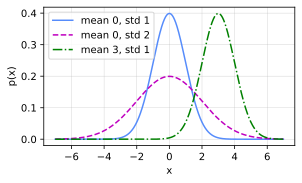

In [8]:
x = np.arange(-7, 7, 0.01)

# pairs of mean and standard deviation
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
        ylabel='p(x)', figsize=(4.5, 2.5),
        legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

As we can see, **changing the mean results in a shift along the x-axis, while increasing the variance causes the distribution to spread out and reduces its peak.**<br><br>
**One reason the mean squared error loss function (often abbreviated as mean squared loss) can be used in linear regression is that we assume the observations contain noise that follows a normal distribution.** The normal distribution of the noise is given by the following equation:
##### **(3.1.12)**
$$y=w^{T}x+b+\mathcal{X}$$
In particular, $X \sim \mathcal{N}(\mu, \sigma^{2})$.
Therefore, we can now write the likelihood of observing a specific y given a given x:
##### **(3.1.13)**
$$P(y|x)=\frac{1}{\sqrt{2\pi\sigma^{2}}}exp\left(-\frac{1}{2\sigma^{2}}(y-w^{T}x-b)^{2}\right)$$
Now, according to the maximum likelihood estimation method, the optimal values of the parameters $w$ and $b$ are those that maximize the likelihood over the entire dataset:
##### **(3.1.14)**
$$P(y|X)=\prod\limits_{i=1}^{n}p(y^{(i)}|x^{(i)})$$
An estimator selected using the maximum likelihood estimation method is called a maximum likelihood estimator. **Although maximizing the product of many exponential functions may seem difficult, we can simplify the problem by maximizing the log-likelihood without changing the objective.** For historical reasons, optimization is typically referred to as minimization rather than maximization. We can instead minimize the negative log-likelihood: $−log P(y|X)$. The resulting mathematical formula is:
##### **(3.1.15)**
$$=logP(y|X)=\sum\limits_{i=1}^{n}\frac{1}{2}log(2\pi\sigma^{2})+\frac{1}{2\sigma^{2}}\left(y^{(i)}-w^{T}x^{(i)}-b\right)^{2}$$
Now, we can simply assume that $\sigma$ is a fixed constant and ignore the first term, since it does not depend on $w$ and $b$. The second term, apart from the constant $\frac{1}{\sigma^2}$, is identical to the mean squared error introduced earlier. **Fortunately, the solution to the above equation does not depend on $\sigma$. Therefore, under the assumption of Gaussian noise, minimizing the mean squared error is equivalent to obtaining the maximum likelihood estimate of the linear model.**

## **3.1.4 From Linear Regression to Deep Neural Networks**
Although neural networks encompass a wider variety of models, we can still describe linear models using the terminology of neural networks, thereby viewing linear models as neural networks. First, we’ll rewrite this model using the “layer” notation.

### **Neural Network Diagram**
Deep learning practitioners like to draw diagrams to visualize what is happening inside a model. In Figure [3.1.2](#fig312), we depict a linear regression model as a neural network. **It is important to note that this figure shows only the connection patterns—that is, it shows only how each input is connected to the output—while omitting the values of the weights and biases.**
##### **Fig(3.1.2)**
![Neural netword of linear regression](../images/picture3_1_2.png)<br><br>
The inputs are $x1, ..., xd$, so the number of inputs in the input layer (also known as feature dimensionality) is $d$. The network’s output is $o1$, so the number of outputs in the output layer is 1. It is important to note that the input values are all predefined, and there is only one computational neuron. **Since the model focuses on where the computation takes place, we typically do not count the input layer when determining the number of layers.** In other words, the neural network in Figure [3.1.2](#fig312) has one layer. We can view a linear regression model as a neural network consisting of a single artificial neuron, also known as a single-layer neural network.<br><br>
**In linear regression, each input is connected to each output (in this example, there is only one output). We refer to this transformation (the output layer in Figure [3.1.2](#fig312)) as a fully-connected layer or a dense layer**.

## **Summary**
* The key components of a machine learning model are the training data, the loss function, the optimization algorithm, and the model itself.
* Vectorization makes mathematical expressions more concise and also speeds up execution.
* Minimizing the objective function is equivalent to performing maximum likelihood estimation.
* A linear regression model is also a simple neural network.